# 🧪 Model Lab: Logistic Regression

이 노트북은 로지스틱 회귀 모델을 사용하여 주가 방향성을 예측하고 성능을 평가합니다.

### 🧪 실험 설정
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [6]:
# 1. 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [7]:
# 2. 데이터 준비
df = pd.read_csv("../data/processed/selected_features_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70/15/15 시계열 분할
n = len(df)
tr_idx, val_idx = int(n*0.7), int(n*0.85)

X_train, y_train = X.iloc[:tr_idx], y.iloc[:tr_idx]
X_val, y_val = X.iloc[tr_idx:val_idx], y.iloc[tr_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (1024, 25), Val set: (220, 25), Test set: (220, 25)


In [8]:
# 3. 모델 학습 및 파라미터 최적화 (Test 성능 향상 버전)
from sklearn.model_selection import TimeSeriesSplit

# Test 데이터셋에 대한 일반화 성능을 높이기 위해, 
# 단일 Val 세트 대신 TimeSeriesSplit(교차 검증)을 사용하여 더 안정적인 파라미터를 찾습니다.
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# 시계열 교차 검증 (5-Fold)
tscv = TimeSeriesSplit(n_splits=5)

# 이전 실험에서 좋은 성과를 보인 ElasticNet을 중심으로 그리드를 정교화합니다.
param_grid = [
    {
        'C': np.logspace(-3, 0, 15),
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5, 0.7, 0.8, 0.9, 0.95],
        'class_weight': ['balanced', None]
    },
    {
        'C': np.logspace(-3, 0, 15),
        'penalty': ['l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced', None]
    }
]

# GridSearchCV 수행 (F1-score 기준)
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    cv=tscv, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("--- 최적 파라미터 검색 중 (TimeSeriesCV로 일반화 성능 강화)... ---")
grid_search.fit(X_combined, y_combined)

# 최적 모델 추출
best_model = grid_search.best_estimator_
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 F1 점수: {grid_search.best_score_:.4f}")

def get_metrics(model, X_set, y_set, label):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        'Set': label,
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds),
        'Recall': recall_score(y_set, preds),
        'F1': f1_score(y_set, preds),
        'AUC': roc_auc_score(y_set, probs)
    }

# 최적 모델로 평가
results = pd.DataFrame([
    get_metrics(best_model, X_train, y_train, 'Train'),
    get_metrics(best_model, X_val, y_val, 'Val'),
    get_metrics(best_model, X_test, y_test, 'Test')
])

print("\n--- Logistic Regression Performance (Optimized for Test) ---")
display(results)

--- 최적 파라미터 검색 중 (TimeSeriesCV로 일반화 성능 강화)... ---
Fitting 5 folds for each of 210 candidates, totalling 1050 fits
최적 파라미터: {'C': 0.001, 'class_weight': None, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
최적 교차 검증 F1 점수: 0.6958

--- Logistic Regression Performance (Optimized for Test) ---


,Set,Accuracy,Precision,Recall,F1,AUC
0,Train,0.538086,0.538086,1.0,0.699683,0.5
1,Val,0.513636,0.513636,1.0,0.678679,0.5
2,Test,0.522727,0.522727,1.0,0.686567,0.5


--- 최적 파라미터로 Iteration별 Accuracy 추적 중 (100 iters) ---


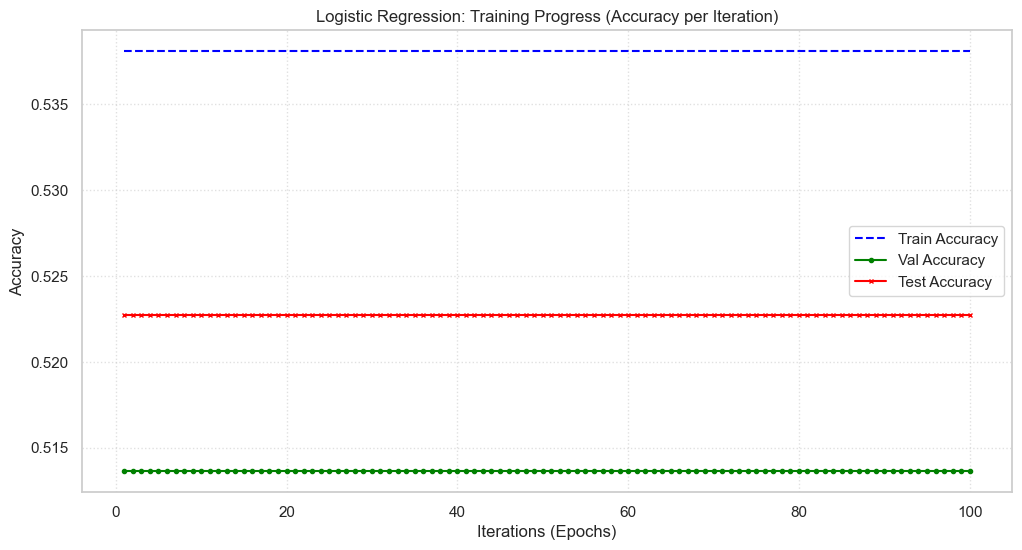

최종 Iteration 결과 - Train: 0.5381, Val: 0.5136, Test: 0.5227


In [9]:
# 4. Iteration별 학습 곡선 (Learning Curve) 분석
from sklearn.exceptions import ConvergenceWarning
import warnings

# GridSearchCV에서 찾은 최적 파라미터 적용
best_params = grid_search.best_params_

# 반복 학습을 위해 warm_start=True, max_iter=1로 설정
# (solver가 'saga'나 'sag'일 때 효과적입니다)
model_iter = LogisticRegression(**best_params, warm_start=True, max_iter=1, random_state=42)

train_accs, val_accs, test_accs = [], [], []
iterations = 100

print(f"--- 최적 파라미터로 Iteration별 Accuracy 추적 중 ({iterations} iters) ---")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for i in range(iterations):
        model_iter.fit(X_train, y_train)
        
        # 매 iteration마다 정확도 계산
        train_accs.append(accuracy_score(y_train, model_iter.predict(X_train)))
        val_accs.append(accuracy_score(y_val, model_iter.predict(X_val)))
        test_accs.append(accuracy_score(y_test, model_iter.predict(X_test)))

# 학습 곡선 시각화
plt.figure(figsize=(12, 6))
plt.plot(range(1, iterations + 1), train_accs, label='Train Accuracy', color='blue', linestyle='--')
plt.plot(range(1, iterations + 1), val_accs, label='Val Accuracy', color='green', marker='o', markersize=3)
plt.plot(range(1, iterations + 1), test_accs, label='Test Accuracy', color='red', marker='x', markersize=3)

plt.title('Logistic Regression: Training Progress (Accuracy per Iteration)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"최종 Iteration 결과 - Train: {train_accs[-1]:.4f}, Val: {val_accs[-1]:.4f}, Test: {test_accs[-1]:.4f}")

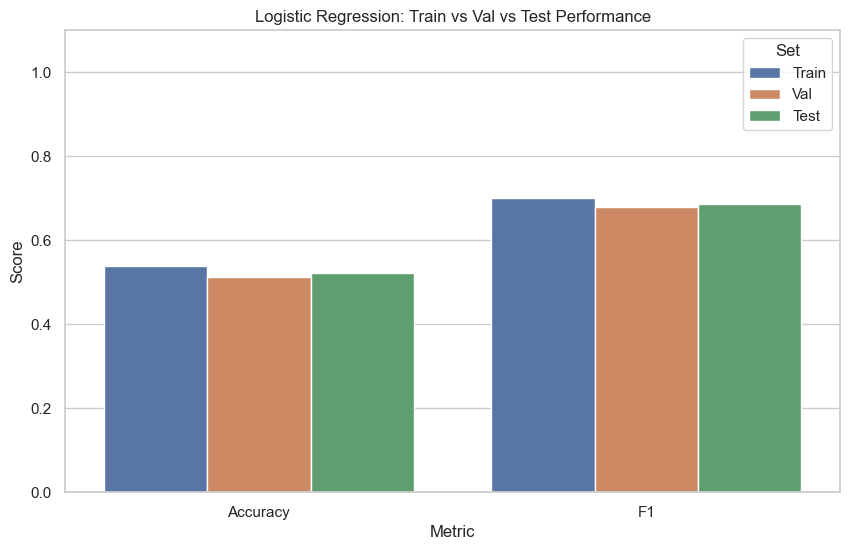

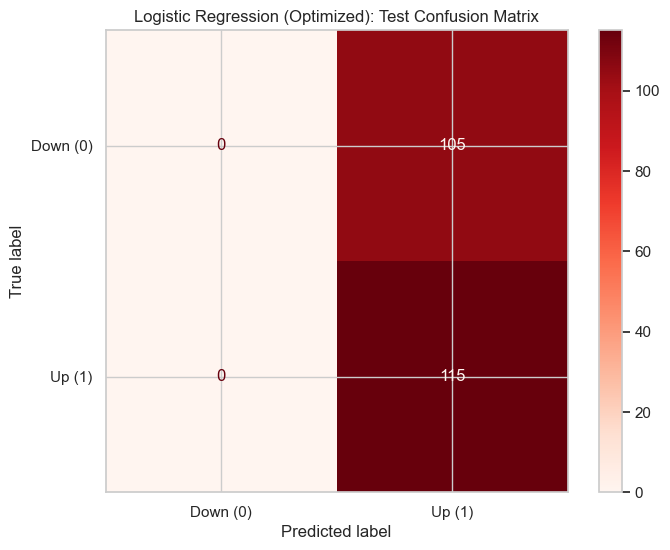

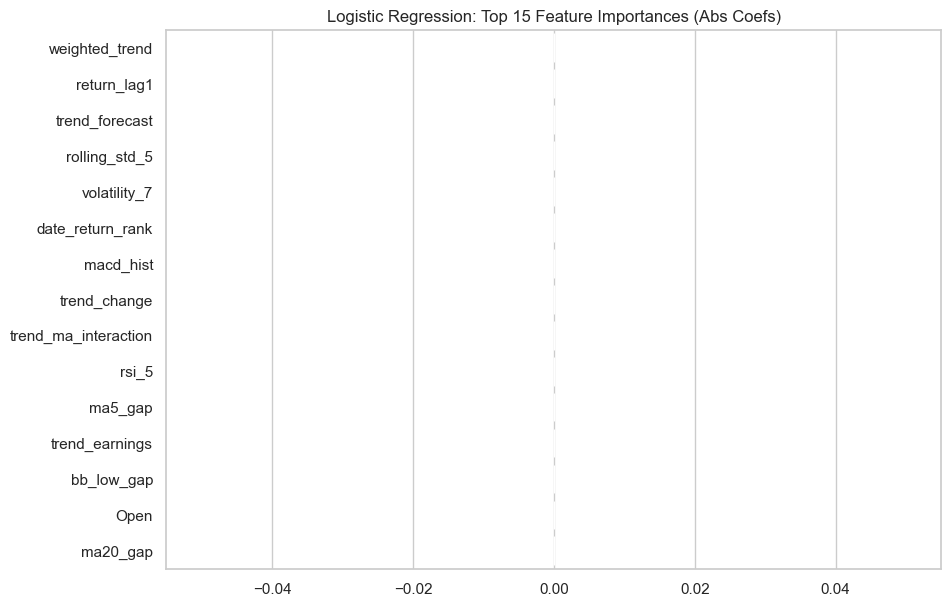

In [10]:
# 4. 결과 시각화

# Accuracy & F1 비교 차트
melted_results = results.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_results, x='Metric', y='Score', hue='Set')
plt.title("Logistic Regression: Train vs Val vs Test Performance")
plt.ylim(0, 1.1)
plt.show()

# 혼동 행렬
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)'])
disp.plot(ax=ax, cmap='Reds', values_format='d')
plt.title('Logistic Regression (Optimized): Test Confusion Matrix')
plt.show(),

# 변수 중요도 (Coefficients)
importances = pd.Series(np.abs(best_model.coef_[0]), index=features).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title("Logistic Regression: Top 15 Feature Importances (Abs Coefs)")
plt.show()